In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Open the GEBCO NetCDF file
file_path = "/Users/lb962/Documents/Phd/AExtremesEOF/data/GEBCO/gebco_2024_n70.0_s47.0_w-20.0_e15.0.nc"
GEBCO_ds = xr.open_dataset(file_path)

In [2]:
import os
import xarray as xr
import pandas as pd

# Set directory
#output_directory = "/Users/lb962/Documents/GitHub/ESL/data/processed_GESLA"

# Get list of all NetCDF files in the directory
#nc_files = [os.path.join(output_directory, f) for f in os.listdir(output_directory) if f.endswith('.nc')]

# Load and concatenate datasets along a new dimension if needed
#ds = xr.open_mfdataset(nc_files, combine='by_coords')  # or combine='nested' with concat_dim='time' if needed
ds = xr.open_dataset("/Users/lb962/Documents/GitHub/ESL/data/processed/filtered_GESLA_sea_level.nc")
lat = ds['latitude'].values
lon = ds['longitude'].values

# If lat/lon are scalars or arrays, pair them
latlon_pairs = list(zip(lat.flatten(), lon.flatten()))
unique_latlon = list(set(latlon_pairs))  # remove duplicates

In [3]:
unique_latlon 

[(51.827801, -8.0007),
 (51.659342, 4.144264),
 (55.627399, -6.1901002),
 (51.675798, 3.756442),
 (58.457199, -5.0496001),
 (51.773558, 4.192415),
 (54.650722, -3.567167),
 (51.819721, 4.128239),
 (54.6364, -8.3949),
 (58.974339, 5.730121),
 (57.8955, -5.1567998),
 (49.9179, -6.3155999),
 (55.0, 9.9833002),
 (54.8424, -5.1188998),
 (52.462323, 4.554823),
 (52.473083, 1.75025),
 (58.006377, 7.554759),
 (55.989833, -3.181694),
 (51.442308, 3.596057),
 (52.016701, -4.9833298),
 (51.716702, -5.0500002),
 (51.38198, 1.11553),
 (51.626665, 4.254928),
 (50.65112, -1.15317),
 (51.57, -3.975472),
 (51.521445, 3.440031),
 (55.749699, -4.9046998),
 (51.595404, 4.006011),
 (60.398046, 5.320487),
 (60.155, -1.14),
 (50.802194, -1.11125),
 (55.749806, -4.906333),
 (58.440972, -3.086389),
 (50.60935, -1.94918),
 (51.60088, 3.85938),
 (58.006378, 7.554759),
 (50.9693985, 1.86772001),
 (54.085222, -4.768056),
 (54.665001, -5.6691999),
 (50.727501, 1.5774),
 (51.116699, 1.3166699),
 (60.154028, -1.14030

In [3]:
unique_latlon[:2]

[(51.827801, -8.0007), (51.659342, 4.144264)]

In [4]:
# Function to extract square around a lat/lon
def extract_square(ds, lat, lon, size_deg):
    half = size_deg / 2
    return ds.sel(
        lat=slice(lat + half, lat - half),  # GEBCO lat usually descending
        lon=slice(lon - half, lon + half),
        method="nearest"
    )

results = {
    "0.1x0.1": [],
    "0.25x0.25": [],
    "1x1": [],
    "3x3": [],
    "10x10":[]
}

In [5]:
def extract_square(ds, lat, lon, size_deg):
    half = size_deg / 2
    return ds.where(
        (ds.lat >= lat - half) & (ds.lat <= lat + half) &
        (ds.lon >= lon - half) & (ds.lon <= lon + half),
        drop=True  # drops points outside the box
    )
for lat, lon in unique_latlon[:20]:
    results["0.1x0.1"].append(extract_square(GEBCO_ds, lat, lon, 0.1))
    results["0.25x0.25"].append(extract_square(GEBCO_ds, lat, lon, 0.25))
    results["1x1"].append(extract_square(GEBCO_ds, lat, lon, 1))
    results["3x3"].append(extract_square(GEBCO_ds, lat, lon, 3))
    results["10x10"].append(extract_square(GEBCO_ds, lat, lon, 10))


In [6]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

def mask_land_gt1m(ds_tile):
    """Mask elevations shallower than -0.5 m (land/coast) as NaN."""
    ds_masked = ds_tile.copy()
    ds_masked["elevation"] = ds_tile["elevation"].where(ds_tile["elevation"] <= -0.5)
    return ds_masked

def plot_tile(ds_tile, title="GEBCO bathymetry (masked, with station)"):
    """Plot a masked GEBCO tile with Cartopy and a red station dot at the center."""
    masked = mask_land_gt1m(ds_tile)

    # Compute the center coordinate (station location)
    center_lat = float(masked.lat.mean())
    center_lon = float(masked.lon.mean())
    
    fig = plt.figure(figsize=(6, 4))
    ax = plt.axes(projection=ccrs.PlateCarree())

    # Bathymetry raster
    pcm = ax.pcolormesh(
        masked["lon"], masked["lat"], masked["elevation"],
        transform=ccrs.PlateCarree()
    )

    # Coastlines and extent
    ax.coastlines(resolution="10m")
    ax.set_title(title)
    ax.set_extent([
        float(masked.lon.min()), float(masked.lon.max()),
        float(masked.lat.min()), float(masked.lat.max())
    ], crs=ccrs.PlateCarree())

    # Station red dot
    ax.plot(center_lon, center_lat, 'ro', markersize=6, transform=ccrs.PlateCarree())

    # Colorbar
    plt.colorbar(pcm, ax=ax, label="Elevation (m)")
    plt.show()



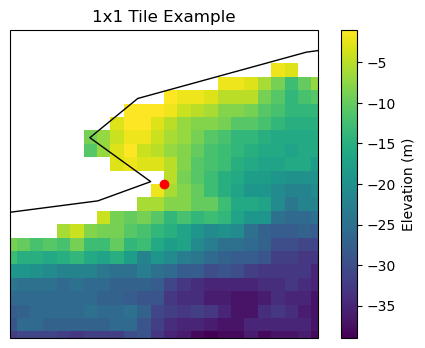

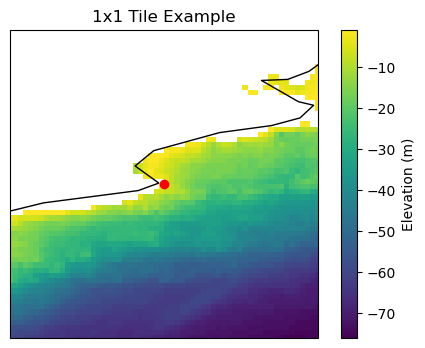

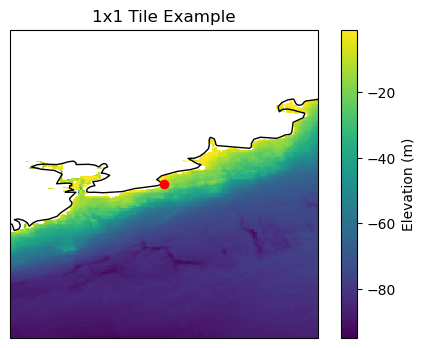

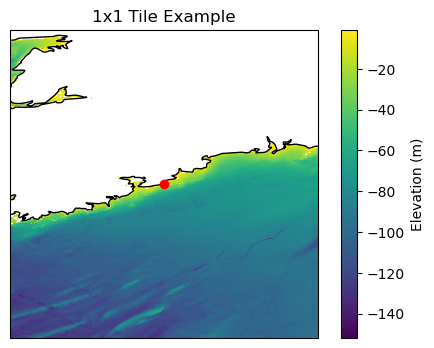

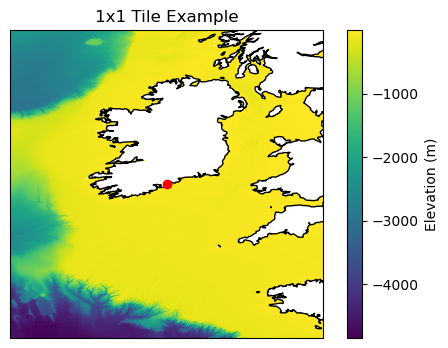

In [60]:
plot_tile(results["0.1x0.1"][0], title="1x1 Tile Example")
plot_tile(results["0.25x0.25"][0], title="1x1 Tile Example")
plot_tile(results["1x1"][0], title="1x1 Tile Example")
plot_tile(results["3x3"][0], title="1x1 Tile Example")
plot_tile(results["10x10"][0], title="1x1 Tile Example")

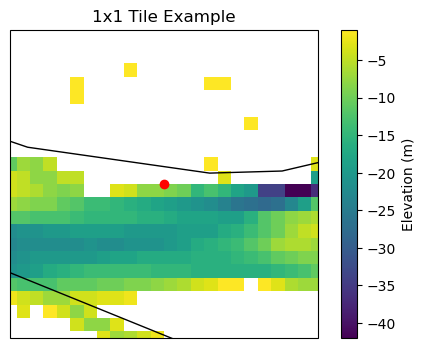

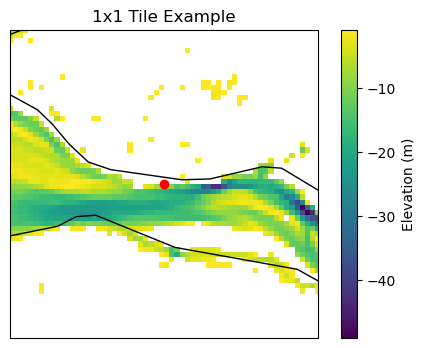

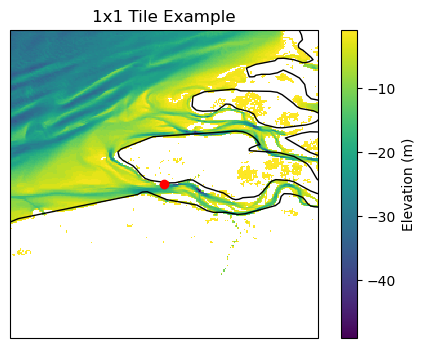

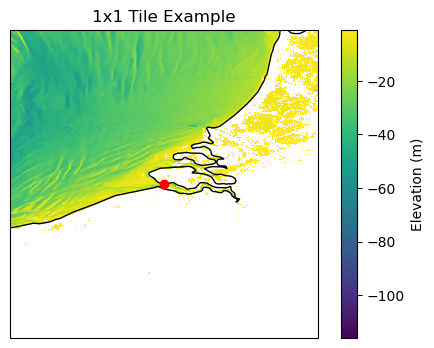

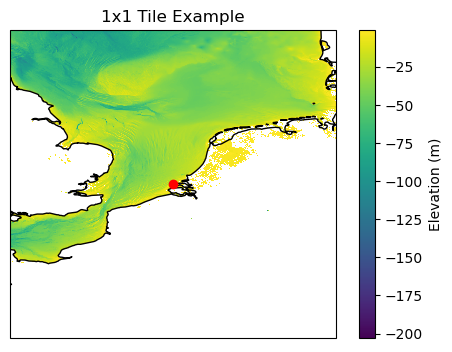

In [61]:
plot_tile(results["0.1x0.1"][20], title="1x1 Tile Example")
plot_tile(results["0.25x0.25"][20], title="1x1 Tile Example")
plot_tile(results["1x1"][20], title="1x1 Tile Example")
plot_tile(results["3x3"][20], title="1x1 Tile Example")
plot_tile(results["10x10"][20], title="1x1 Tile Example")

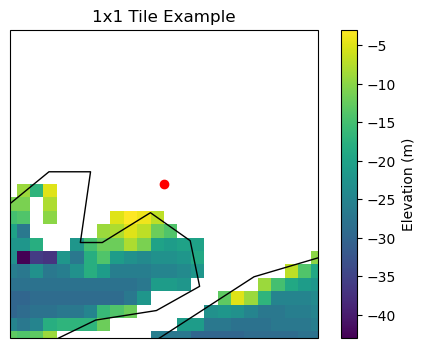

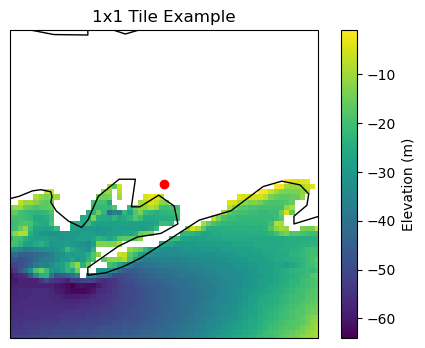

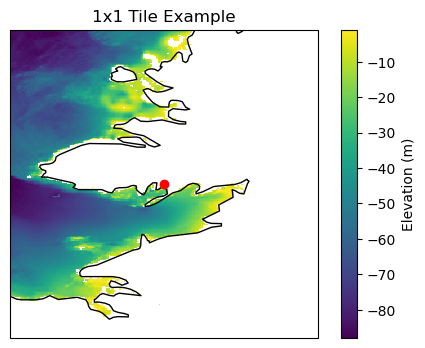

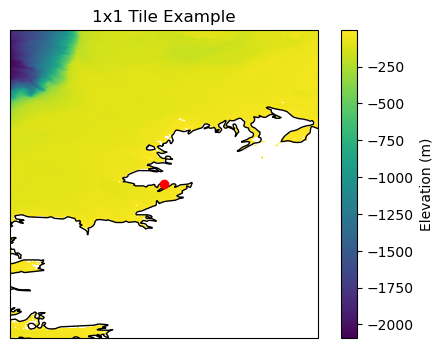

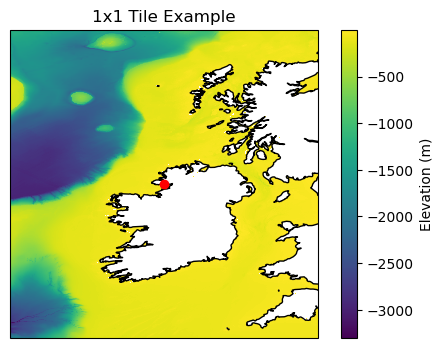

In [62]:
plot_tile(results["0.1x0.1"][10], title="1x1 Tile Example")
plot_tile(results["0.25x0.25"][10], title="1x1 Tile Example")
plot_tile(results["1x1"][10], title="1x1 Tile Example")
plot_tile(results["3x3"][10], title="1x1 Tile Example")
plot_tile(results["10x10"][10], title="1x1 Tile Example")

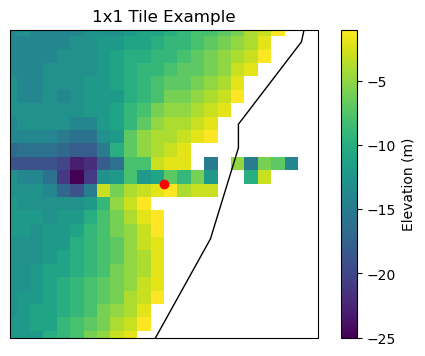

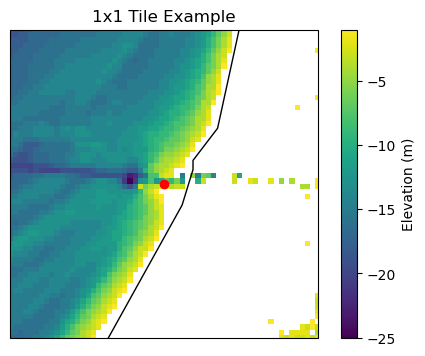

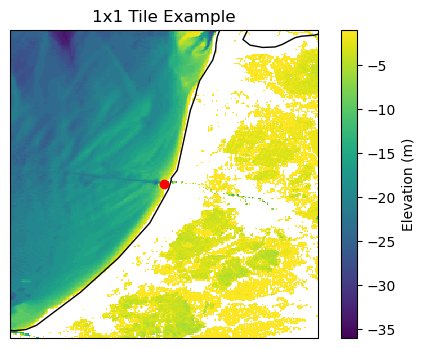

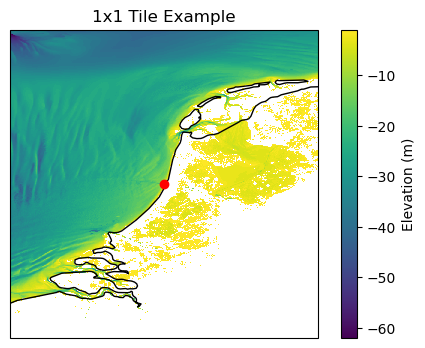

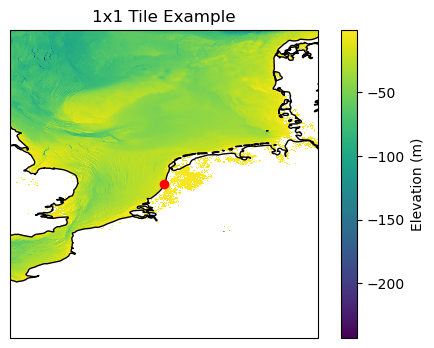

In [65]:
plot_tile(results["0.1x0.1"][16], title="1x1 Tile Example")
plot_tile(results["0.25x0.25"][16], title="1x1 Tile Example")
plot_tile(results["1x1"][16], title="1x1 Tile Example")
plot_tile(results["3x3"][16], title="1x1 Tile Example")
plot_tile(results["10x10"][16], title="1x1 Tile Example")

In [12]:
import torch, numpy as np, random
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

SCALES = ["0.1x0.1","0.25x0.25","1x1","3x3","10x10"]
IMG_SIZE = 128

def xarray_tile_to_tensor(ds_tile, size=IMG_SIZE):
    z = ds_tile["elevation"].values.astype(np.float32)
    valid = ~np.isnan(z)
    mask = valid.astype(np.float32)
    if valid.any():
        m = z[valid].mean(); s = z[valid].std() + 1e-6
        z = (z - m) / s
    z = np.nan_to_num(z, nan=0.0)
    arr = np.stack([z, mask], axis=0)             # (2,H,W)
    t = torch.from_numpy(arr).unsqueeze(0)        # (1,2,H,W)
    t = F.interpolate(t, size=(size, size), mode="bilinear", align_corners=False).squeeze(0)
    return t                                      # (2,128,128)

def aug(x):
    if random.random()<0.5: x = torch.flip(x, dims=[2])
    if random.random()<0.5: x = torch.flip(x, dims=[1])
    if random.random()<0.5:
        x0 = x[0] + torch.randn_like(x[0])*0.02   # noise on elevation only
        x = torch.stack([x0, x[1]], dim=0)
    return x

class BathyTiles(Dataset):
    def __init__(self, results, mask_fn, scales=SCALES, sites=None, augment=True):
        self.results, self.mask_fn, self.scales, self.augment = results, mask_fn, list(scales), augment
        n = min(len(results[s]) for s in scales)
        self.sites = range(n) if sites is None else sites
        self.samples = [(s, i) for i in self.sites for s in self.scales]  # more samples
    def __len__(self): return len(self.samples)
    def __getitem__(self, idx):
        s, i = self.samples[idx]
        ds = self.mask_fn(self.results[s][i])
        x = xarray_tile_to_tensor(ds)
        if self.augment: x = aug(x)
        # Return: input is 2-ch (z_norm + mask); target is elevation channel only
        return x, x[:1], x[1:2]  # (2,H,W), (1,H,W)=target, (1,H,W)=ocean mask


In [17]:
import torch
import torch.nn as nn

EMB_DIM = 128  # bottleneck size; change if you want

class Encoder(nn.Module):
    """
    128x128 -> 64 -> 32 -> 16 -> 8
    Conv blocks: 16, 32, 64, 128 filters with 3x3 kernels (paper-style).
    """
    def __init__(self, in_ch=2, emb_dim=EMB_DIM):
        super().__init__()
        self.c1 = nn.Sequential(nn.Conv2d(in_ch, 16, 3, padding=1), nn.ReLU(inplace=True))
        self.p1 = nn.MaxPool2d(2)   # 128 -> 64
        self.c2 = nn.Sequential(nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(inplace=True))
        self.p2 = nn.MaxPool2d(2)   # 64 -> 32
        self.c3 = nn.Sequential(nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(inplace=True))
        self.p3 = nn.MaxPool2d(2)   # 32 -> 16
        self.c4 = nn.Sequential(nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(inplace=True))
        self.p4 = nn.MaxPool2d(2)   # 16 -> 8

        self.proj = nn.Linear(128 * 8 * 8, emb_dim)

    def forward(self, x):
        x = self.p1(self.c1(x))
        x = self.p2(self.c2(x))
        x = self.p3(self.c3(x))
        x = self.p4(self.c4(x))     # (B,128,8,8)
        b, c, h, w = x.shape
        z = self.proj(x.view(b, c * h * w))  # (B, emb_dim)
        return z


class Decoder(nn.Module):
    """
    8 -> 16 -> 32 -> 64 -> 128 using ConvTranspose2d (k=4, s=2, p=1)
    Mirrors the encoder channel widths down to the 1-channel output.
    """
    def __init__(self, emb_dim=EMB_DIM, out_ch=1):
        super().__init__()
        self.fc  = nn.Linear(emb_dim, 128 * 8 * 8)
        self.d1  = nn.Sequential(nn.ConvTranspose2d(128, 128, 4, stride=2, padding=1), nn.ReLU(inplace=True))  # 8->16
        self.d2  = nn.Sequential(nn.ConvTranspose2d(128, 64,  4, stride=2, padding=1), nn.ReLU(inplace=True))  # 16->32
        self.d3  = nn.Sequential(nn.ConvTranspose2d(64,  32,  4, stride=2, padding=1), nn.ReLU(inplace=True))  # 32->64
        self.d4  = nn.Sequential(nn.ConvTranspose2d(32,  16,  4, stride=2, padding=1), nn.ReLU(inplace=True))  # 64->128
        self.out = nn.Conv2d(16, out_ch, 1)  # identity activation (good for z-normalized targets)

    def forward(self, z):
        x = self.fc(z).view(-1, 128, 8, 8)
        x = self.d1(x)
        x = self.d2(x)
        x = self.d3(x)
        x = self.d4(x)
        y = self.out(x)  # (B, out_ch, 128, 128)
        return y


class CAE(nn.Module):
    def __init__(self, in_ch=2, emb_dim=EMB_DIM, out_ch=1):
        super().__init__()
        self.encoder = Encoder(in_ch=in_ch, emb_dim=emb_dim)
        self.decoder = Decoder(emb_dim=emb_dim, out_ch=out_ch)

    def forward(self, x):
        z = self.encoder(x)
        y = self.decoder(z)
        return z, y


In [18]:
def masked_l1(pred, target, mask):
    w = mask
    return (w * (pred - target).abs()).sum() / w.sum().clamp_min(1.0)

device = "cuda" if torch.cuda.is_available() else "cpu"
model = CAE(in_ch=2, emb_dim=128).to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)  # paper


In [19]:
# station-blocked split (better validation)
num_sites = min(len(results[s]) for s in SCALES)
sites = list(range(num_sites))
split = int(0.8 * num_sites)
train_sites, val_sites = sites[:split], sites[split:]

train_ds = BathyTiles(results, mask_land_gt1m, SCALES, sites=train_sites, augment=True)
val_ds   = BathyTiles(results, mask_land_gt1m, SCALES, sites=val_sites,   augment=False)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=64, shuffle=False, num_workers=0)


epoch 1: train 0.4645 | val 0.4759
epoch 2: train 0.4593 | val 0.4760
epoch 3: train 0.4564 | val 0.4704
epoch 4: train 0.4513 | val 0.4687
epoch 5: train 0.4568 | val 0.4702
epoch 6: train 0.4434 | val 0.4624
epoch 7: train 0.4372 | val 0.4587
epoch 8: train 0.4266 | val 0.4612
epoch 9: train 0.4310 | val 0.4663
epoch 10: train 0.4266 | val 0.4611
epoch 11: train 0.4230 | val 0.4544
epoch 12: train 0.4163 | val 0.4436
epoch 13: train 0.4123 | val 0.4366
epoch 14: train 0.4115 | val 0.4316
epoch 15: train 0.4069 | val 0.4321
epoch 16: train 0.4052 | val 0.4284
epoch 17: train 0.4048 | val 0.4294
epoch 18: train 0.4005 | val 0.4299
epoch 19: train 0.4006 | val 0.4350
epoch 20: train 0.3925 | val 0.4335
epoch 21: train 0.3950 | val 0.4337
epoch 22: train 0.4031 | val 0.4362
epoch 23: train 0.4039 | val 0.4240
epoch 24: train 0.3878 | val 0.4166
epoch 25: train 0.3813 | val 0.4171
epoch 26: train 0.3814 | val 0.4132
epoch 27: train 0.3777 | val 0.4183
epoch 28: train 0.3781 | val 0.4160
e

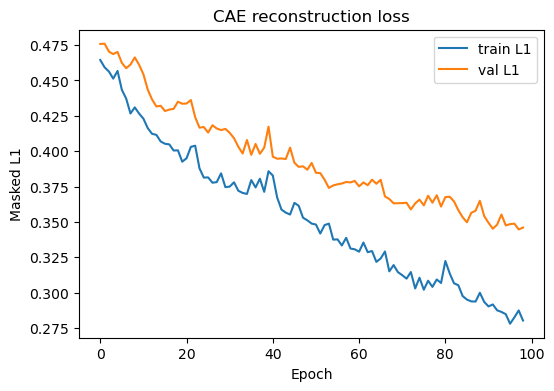

In [23]:
import matplotlib.pyplot as plt
from collections import defaultdict
import torch.nn.functional as F

history = defaultdict(list)

def masked_l1(pred, target, mask):
    return (mask * (pred - target).abs()).sum() / mask.sum().clamp_min(1.0)

# (Optional) SSIM if installed: pip install pytorch-msssim
try:
    from pytorch_msssim import ssim
    def masked_ssim(pred, target, mask):
        # SSIM is high=good; we compute 1-SSIM as a loss-like number
        return 1.0 - ssim(pred*mask, target*mask, data_range=float((pred*mask).amax()-(pred*mask).amin()), size_average=True)
except Exception:
    ssim = None
    masked_ssim = None

best = (1e9, None)
for epoch in range(1, 100):
    # ---- train ----
    model.train(); tr_num=0; tr_den=0; tr_ssim_vals=[]
    for x, tgt, m in train_loader:
        x, tgt, m = x.to(device), tgt.to(device), m.to(device)
        z, recon = model(x)
        loss = masked_l1(recon, tgt, m)
        opt.zero_grad(); loss.backward(); opt.step()

        tr_num += (m * (recon - tgt).abs()).sum().item()
        tr_den += m.sum().item()
        if masked_ssim:
            tr_ssim_vals.append(masked_ssim(recon, tgt, m).item())

    train_l1 = tr_num / max(1.0, tr_den)
    history['train_l1'].append(train_l1)
    if masked_ssim:
        history['train_1-ssim'].append(sum(tr_ssim_vals)/max(1,len(tr_ssim_vals)))

    # ---- val ----
    model.eval(); vl_num=0; vl_den=0; vl_ssim_vals=[]
    with torch.no_grad():
        for x, tgt, m in val_loader:
            x, tgt, m = x.to(device), tgt.to(device), m.to(device)
            _, recon = model(x)
            vl_num += (m * (recon - tgt).abs()).sum().item()
            vl_den += m.sum().item()
            if masked_ssim:
                vl_ssim_vals.append(masked_ssim(recon, tgt, m).item())

    val_l1 = vl_num / max(1.0, vl_den)
    history['val_l1'].append(val_l1)
    if masked_ssim:
        history['val_1-ssim'].append(sum(vl_ssim_vals)/max(1,len(vl_ssim_vals)))

    print(f"epoch {epoch}: train {train_l1:.4f} | val {val_l1:.4f}")
    if val_l1 < best[0]:
        best = (val_l1, {"model": model.state_dict(), "epoch": epoch})

# ----- plots -----
plt.figure(figsize=(6,4))
plt.plot(history['train_l1'], label='train L1')
plt.plot(history['val_l1'],   label='val L1')
plt.xlabel('Epoch'); plt.ylabel('Masked L1'); plt.legend(); plt.title('CAE reconstruction loss')
plt.show()

if masked_ssim and 'val_1-ssim' in history:
    plt.figure(figsize=(6,4))
    plt.plot(history['train_1-ssim'], label='train (1-SSIM)')
    plt.plot(history['val_1-ssim'],   label='val (1-SSIM)')
    plt.xlabel('Epoch'); plt.ylabel('1 - SSIM (lower is better)'); plt.legend(); plt.title('Structural loss')
    plt.show()


In [20]:
best = (1e9, None)
for epoch in range(1, 41):
    model.train(); tr=0; n=0
    for x, tgt, m in train_loader:
        x, tgt, m = x.to(device), tgt.to(device), m.to(device)
        z, recon = model(x)
        loss = masked_l1(recon, tgt, m)
        opt.zero_grad(); loss.backward(); opt.step()
        tr += loss.item() * x.size(0); n += x.size(0)
    tr /= n

    # validate (no augs)
    model.eval(); vl=0; n=0
    with torch.no_grad():
        for x, tgt, m in val_loader:
            x, tgt, m = x.to(device), tgt.to(device), m.to(device)
            _, recon = model(x)
            loss = masked_l1(recon, tgt, m)
            vl += loss.item() * x.size(0); n += x.size(0)
    vl /= n
    print(f"epoch {epoch}: train {tr:.4f} | val {vl:.4f}")

    if vl < best[0]:
        best = (vl, {"model": model.state_dict(), "epoch": epoch})


epoch 1: train 0.7863 | val 0.7746
epoch 2: train 0.7830 | val 0.7539
epoch 3: train 0.7647 | val 0.7346
epoch 4: train 0.7518 | val 0.7340
epoch 5: train 0.7502 | val 0.7139
epoch 6: train 0.7404 | val 0.7139
epoch 7: train 0.7301 | val 0.7166
epoch 8: train 0.7340 | val 0.7189
epoch 9: train 0.7286 | val 0.7207
epoch 10: train 0.7242 | val 0.7383
epoch 11: train 0.7330 | val 0.7229
epoch 12: train 0.7270 | val 0.7227
epoch 13: train 0.7353 | val 0.7194
epoch 14: train 0.7228 | val 0.7255
epoch 15: train 0.7227 | val 0.7104
epoch 16: train 0.7222 | val 0.7039
epoch 17: train 0.7132 | val 0.6915
epoch 18: train 0.7014 | val 0.6770
epoch 19: train 0.6731 | val 0.6552
epoch 20: train 0.6699 | val 0.6542
epoch 21: train 0.6617 | val 0.6662
epoch 22: train 0.6524 | val 0.6406
epoch 23: train 0.6495 | val 0.6392
epoch 24: train 0.6384 | val 0.6424
epoch 25: train 0.6360 | val 0.6172
epoch 26: train 0.6240 | val 0.6123
epoch 27: train 0.6084 | val 0.6064
epoch 28: train 0.5911 | val 0.5923
e

In [77]:
# uses your: mask_land_gt1m(ds_tile), results dict, and tile_to_tensor() idea

import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
import random

SCALES = ["0.1x0.1", "0.25x0.25", "1x1", "3x3", "10x10"]
IMG_SIZE = 128

def xarray_tile_to_tensor(ds_tile, size=IMG_SIZE):
    # ds_tile: xarray Dataset with var "elevation", land masked already (you have mask_land_gt1m)
    import torch.nn.functional as F
    z = ds_tile["elevation"].values.astype(np.float32)
    valid = ~np.isnan(z)
    mask = valid.astype(np.float32)
    if valid.any():
        m = z[valid].mean(); s = z[valid].std() + 1e-6
        z = (z - m) / s
    z = np.nan_to_num(z, nan=0.0)
    arr = np.stack([z, mask], axis=0)  # (2,H,W)
    t = torch.from_numpy(arr).unsqueeze(0)  # (1,2,H,W)
    t = F.interpolate(t, size=(size, size), mode="bilinear", align_corners=False).squeeze(0)
    return t  # (2, size, size)

class BathyTiles(Dataset):
    """Returns single-scale tiles for AE pretraining (more samples)."""
    def __init__(self, results, scales=SCALES, augment=True):
        self.samples = []
        self.scales = scales
        self.augment = augment
        n = min(len(results[s]) for s in scales)
        for s in scales:
            for i in range(n):
                self.samples.append((s, i))
    def __len__(self): return len(self.samples)
    def __getitem__(self, idx):
        s, i = self.samples[idx]
        ds = mask_land_gt1m(results[s][i])
        x = xarray_tile_to_tensor(ds)  # (2,128,128)
        if self.augment:
            x = random_augs(x)
        return x

def random_augs(x):
    # x: (2,H,W), light geometric+noise augs; keep mask channel consistent
    # geometry on both channels, noise only on z_norm (ch 0)
    if random.random() < 0.5:
        x = torch.flip(x, dims=[2])  # horizontal
    if random.random() < 0.5:
        x = torch.flip(x, dims=[1])  # vertical
    if random.random() < 0.3:
        # small translation by up to 4 px
        dy, dx = random.randint(-4,4), random.randint(-4,4)
        pad = torch.nn.ReplicationPad2d((max(dx,0), max(-dx,0), max(dy,0), max(-dy,0)))
        x = pad(x)[:, max(-dy,0):max(-dy,0)+IMG_SIZE, max(-dx,0):max(-dx,0)+IMG_SIZE]
    if random.random() < 0.5:
        noise = torch.randn_like(x[0]) * 0.02
        x[0] = x[0] + noise
    return x


In [78]:
import torch
import torch.nn as nn
import torch.nn.functional as F

EMB_DIM = 128  # size of the bottleneck embedding we’ll export

class Encoder(nn.Module):
    def __init__(self, in_ch=2, emb_dim=EMB_DIM):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, 32, 3, 2, 1), nn.BatchNorm2d(32), nn.ReLU(inplace=True),
            nn.Conv2d(32, 64, 3, 2, 1),    nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.Conv2d(64, 128, 3, 2, 1),   nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.Conv2d(128, 256, 3, 2, 1),  nn.BatchNorm2d(256), nn.ReLU(inplace=True),
        )
        self.proj = nn.Linear(256, emb_dim)

    def forward(self, x):
        h = self.conv(x)             # (B,256,8,8) for 128x128 input
        gap = h.mean(dim=(2,3))      # (B,256)
        z = self.proj(gap)           # (B,emb_dim)
        return z, h

class Decoder(nn.Module):
    def __init__(self, emb_dim=EMB_DIM, out_ch=1):
        super().__init__()
        # start from the encoder's last feature map stats
        self.fc = nn.Linear(emb_dim, 256)
        self.deconv = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 4, 2, 1), nn.BatchNorm2d(128), nn.ReLU(inplace=True),   # 8->16
            nn.ConvTranspose2d(128, 64, 4, 2, 1),  nn.BatchNorm2d(64),  nn.ReLU(inplace=True),   # 16->32
            nn.ConvTranspose2d(64, 32, 4, 2, 1),   nn.BatchNorm2d(32),  nn.ReLU(inplace=True),   # 32->64
            nn.ConvTranspose2d(32, out_ch, 4, 2, 1),                                                # 64->128
        )
    def forward(self, z):
        x = self.fc(z)[:, :, None, None]   # (B,256,1,1)
        x = x.repeat(1,1,8,8)              # broadcast to match encoder last map size
        out = self.deconv(x)               # (B,1,128,128) -> reconstruct z_norm only
        return out

class AutoEncoder(nn.Module):
    def __init__(self, in_ch=2, emb_dim=EMB_DIM):
        super().__init__()
        self.encoder = Encoder(in_ch=in_ch, emb_dim=emb_dim)
        self.decoder = Decoder(emb_dim=emb_dim, out_ch=1)
    def forward(self, x):
        z, feats = self.encoder(x)
        recons = self.decoder(z)
        return z, recons


In [79]:
def masked_l1_loss(pred, target, mask):
    # pred/target: (B,1,H,W) z_norm channel; mask: (B,1,H,W), 1 where valid ocean
    w = mask
    denom = w.sum().clamp_min(1.0)
    return (w * (pred - target).abs()).sum() / denom

In [ ]:
from pathlib import Path

def load_pretrained_or_init(model, ckpt_path=None, map_location="cpu"):
    if ckpt_path and Path(ckpt_path).exists():
        state = torch.load(ckpt_path, map_location=map_location)
        model.load_state_dict(state["model"])
        print(f"Loaded AE from {ckpt_path} (epoch {state.get('epoch','?')})")
    else:
        print("No checkpoint found; using randomly initialized AE.")
    return model

def train_autoencoder(model, train_loader, val_loader=None, epochs=50, lr=1e-3, device="cuda"):
    opt = torch.optim.AdamW(model.parameters(), lr=lr)
    best = (1e9, None)
    for ep in range(1, epochs+1):
        model.train()
        tr_loss = 0.0
        for x in train_loader:
            x = x.to(device)                   # (B,2,128,128)
            z, recon = model(x)
            target = x[:, :1]                  # reconstruct z_norm only (channel 0)
            mask   = x[:, 1:2]                 # valid ocean mask
            loss = masked_l1_loss(recon, target, mask)
            opt.zero_grad(); loss.backward(); opt.step()
            tr_loss += loss.item() * x.size(0)
        tr_loss /= len(train_loader.dataset)

        val_loss = np.nan
        if val_loader:
            model.eval()
            num = 0; s = 0.0
            with torch.no_grad():
                for x in val_loader:
                    x = x.to(device)
                    _, recon = model(x)
                    loss = masked_l1_loss(recon, x[:, :1], x[:, 1:2])
                    s += loss.item() * x.size(0); num += x.size(0)
            val_loss = s / max(1, num)

        print(f"epoch {ep}: train {tr_loss:.4f}" + (f" | val {val_loss:.4f}" if val_loader else ""))
        if val_loader and val_loss < best[0]:
            best = (val_loss, { "model": model.state_dict(), "epoch": ep })
    return best[1]  # best_state_dict or None


TypeError: BathyTiles.__init__() got multiple values for argument 'augment'

In [84]:
device = "cuda" if torch.cuda.is_available() else "cpu"
ae = AutoEncoder(in_ch=2, emb_dim=EMB_DIM).to(device)

# Try to load pretrained:
ae = load_pretrained_or_init(ae, ckpt_path="pretrained_bathy_ae.pt", map_location=device)

# If you need to (re)train:
dataset = BathyTiles(results, augment=True)
n = len(dataset); idx = list(range(n))
random.shuffle(idx); split = int(0.9*n)
train_set = torch.utils.data.Subset(dataset, idx[:split])
val_set   = torch.utils.data.Subset(dataset, idx[split:])
train_loader = DataLoader(train_set, batch_size=64, shuffle=True, num_workers=0)
val_loader   = DataLoader(val_set,   batch_size=64, shuffle=False, num_workers=0)
#train_loader = DataLoader(train_set, batch_size=64, shuffle=True, num_workers=2, pin_memory=True)
#val_loader   = DataLoader(val_set, batch_size=64, shuffle=False, num_workers=2, pin_memory=True)

best_sd = train_autoencoder(ae, train_loader, val_loader, epochs=40, lr=1e-3, device=device)
if best_sd is not None:
    torch.save(best_sd, "bathy_ae_best.pt")
    ae.load_state_dict(best_sd["model"])


No checkpoint found; using randomly initialized AE.
epoch 1: train 1.0968 | val 0.8258
epoch 2: train 0.8670 | val 0.8280
epoch 3: train 0.7956 | val 0.8277
epoch 4: train 0.7755 | val 0.8180
epoch 5: train 0.7632 | val 0.8121
epoch 6: train 0.7608 | val 0.8045
epoch 7: train 0.7556 | val 0.8048
epoch 8: train 0.7525 | val 0.8081
epoch 9: train 0.7522 | val 0.8067
epoch 10: train 0.7459 | val 0.8072
epoch 11: train 0.7434 | val 0.7972
epoch 12: train 0.7394 | val 0.7964
epoch 13: train 0.7398 | val 0.7941
epoch 14: train 0.7325 | val 0.7961
epoch 15: train 0.7231 | val 0.7966
epoch 16: train 0.7217 | val 0.8031
epoch 17: train 0.7160 | val 0.7919
epoch 18: train 0.7124 | val 0.7896
epoch 19: train 0.7096 | val 0.8021
epoch 20: train 0.7076 | val 0.7928
epoch 21: train 0.7095 | val 0.7892
epoch 22: train 0.7057 | val 0.8109
epoch 23: train 0.7074 | val 0.8036
epoch 24: train 0.7062 | val 0.7848
epoch 25: train 0.7031 | val 0.7803
epoch 26: train 0.7024 | val 0.7737
epoch 27: train 0.702

In [68]:
import numpy as np
import torch
import torch.nn.functional as F

# assumes your mask_land_gt1m(ds_tile) is defined (keeps ocean ≤ -0.5 m)

def tile_to_tensor(ds_tile, size=128):
    """xarray -> (2, size, size): z_norm + valid_mask."""
    # land masked already
    z = ds_tile["elevation"].values.astype(np.float32)
    valid = ~np.isnan(z)
    mask = valid.astype(np.float32)

    if valid.any():
        m = z[valid].mean()
        s = z[valid].std() + 1e-6
        z = (z - m) / s
    z = np.nan_to_num(z, nan=0.0)

    arr = np.stack([z, mask], axis=0)  # (2, H, W)
    t = torch.from_numpy(arr).unsqueeze(0)  # (1,2,H,W)
    t = F.interpolate(t, size=(size, size), mode="bilinear", align_corners=False)
    return t.squeeze(0).contiguous()        # (2,size,size)


In [69]:
import torch.nn as nn
import torch.nn.functional as F

class TinyCNN(nn.Module):
    def __init__(self, in_ch=2, emb_dim=128):
        super().__init__()
        self.backbone = nn.Sequential(
            nn.Conv2d(in_ch, 32, 3, 2, 1), nn.BatchNorm2d(32), nn.ReLU(inplace=True),
            nn.Conv2d(32, 64, 3, 2, 1),    nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.Conv2d(64, 128, 3, 2, 1),   nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.Conv2d(128, 256, 3, 2, 1),  nn.BatchNorm2d(256), nn.ReLU(inplace=True),
        )
        self.head = nn.Linear(256, emb_dim)

    def forward(self, x):              # (B,2,128,128)
        h = self.backbone(x)           # (B,256,8,8)
        h = h.mean(dim=(2,3))          # GAP -> (B,256)
        z = self.head(h)               # (B,emb_dim)
        return F.normalize(z, dim=1)   # L2 norm


class MultiScaleEmbedder(nn.Module):
    def __init__(self, in_ch=2, emb_dim=128, scales=5, agg="concat"):
        super().__init__()
        self.encoder = TinyCNN(in_ch=in_ch, emb_dim=emb_dim)
        self.agg = agg
        if agg == "attn":
            self.attn = nn.Sequential(nn.Linear(emb_dim, 64), nn.ReLU(), nn.Linear(64, 1))

    def forward(self, xs):             # xs: list of tensors [(B,2,128,128)] len=S
        embs = [self.encoder(x) for x in xs]            # list of (B,D)
        if self.agg == "concat":
            site = torch.cat(embs, dim=1)               # (B, S*D)
        else:
            E = torch.stack(embs, dim=1)                # (B,S,D)
            w = torch.softmax(self.attn(E), dim=1)      # (B,S,1)
            site = (E * w).sum(dim=1)                   # (B,D)
        return site, embs


In [ ]:
# Order your five scales (must match your results keys)
SCALES = ["0.1x0.1", "0.25x0.25", "1x1", "3x3", "10x10"]

# Build a list of sites; each site has 5 tiles (one per scale)
num_sites = min(len(results[s]) for s in SCALES)

def site_tiles(i):
    """Return masked tiles for site i across five scales (as xarray Datasets)."""
    return [mask_land_gt1m(results[s][i]) for s in SCALES]

def site_tensors(i, size=128):
    """Return list of (1,2,size,size) tensors for site i across scales."""
    ts = []
    for ds in site_tiles(i):
        t = tile_to_tensor(ds, size=size)   # (2,H,W)
        ts.append(t.unsqueeze(0))           # (1,2,H,W)
    return ts


In [ ]:
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = MultiScaleEmbedder(in_ch=2, emb_dim=128, scales=len(SCALES), agg="concat").to(device)
model.eval()

all_feats = []
with torch.no_grad():
    for i in range(num_sites):
        xs = [t.to(device) for t in site_tensors(i, size=128)]   # list of (1,2,128,128)
        site_emb, _ = model(xs)                                  # (1, 5*128) = (1,640)
        all_feats.append(site_emb.squeeze(0).cpu().numpy())

static_features = np.vstack(all_feats)  # (N, 640)

# Example: pair with your station metadata
# station_meta = [{"lat":..., "lon":...}, ...]
# Save to disk as your "static morphological features"
# np.save("static_features_gecbo_v1.npy", static_features)


In [76]:
static_features[0]

array([ 7.78350309e-02,  1.33560393e-02,  6.99696690e-03,  1.63917840e-01,
       -6.58694804e-02,  7.11166486e-02,  6.08849525e-03, -1.26373053e-01,
       -4.29219939e-02,  1.71173841e-01,  2.92821769e-02, -7.62265176e-02,
       -3.93436141e-02,  8.35030451e-02, -1.37398303e-01,  5.16763963e-02,
        1.22737676e-01, -4.62914780e-02, -4.32705581e-02, -1.25925928e-01,
       -1.38383418e-01,  1.02028340e-01, -6.66861385e-02, -1.32376151e-02,
        1.20923690e-01, -8.38194974e-03,  3.50147560e-02, -1.51323415e-02,
        7.16909841e-02, -1.72105059e-02,  7.88039342e-02,  1.18648820e-01,
       -5.77954091e-02,  1.26934275e-01,  8.93135145e-02, -3.00139412e-02,
       -1.49981514e-01, -1.43921703e-01, -1.47170201e-01, -1.04506649e-01,
       -1.89940482e-02,  1.11535778e-02,  8.72404948e-02, -1.44044440e-02,
        1.09327268e-02,  5.21864071e-02, -1.15874708e-01,  1.38820842e-01,
       -1.72692724e-02, -1.11055352e-01, -8.08839221e-03, -8.56536701e-02,
       -1.07190542e-01,  